In [20]:
import pandas as pd
import numpy as np

DATA DESCRIPTION
```
file name -> Columns
quater-i.csv -> ['order_id', 'quantity', 'item_id', 'choice_description_id' 'item_price']
items.csv -> ['item_id', 'item_name']
```
Dataset Link - https://drive.google.com/drive/folders/1Z0kaFybvgFeczeUj4dldUnhTdloLqLsL?usp=share_link

In [79]:
# Load files
q1 = pd.read_csv("quarter-1.csv")
q2 = pd.read_csv("quarter-2.csv")
items = pd.read_csv("items.csv")


###`Q:1-5`
1. You are given three quater files, your job is to append these three files and make a single dataframe.
2. Have a index as Q-1 Q-2 Q-3 for respective quater files in the dataframe
3. Your are given a file items.csv which has item_id and item_name. Find out most sold items in each quarter.
4. Find out items which has made most revenue in each quarter.
5. Find out avg order price of each quarter.

***Note: item_price is given as str with $ sign, in earlier task you have converted this to rupees, here too first convert item_price field in rupees.***

In [82]:
# Q1-2. You are given three quater files, your job is to append these three files and make a single dataframe.
sales_df = pd.concat([q1, q2], keys=["Q-1", "Q-2"]).reset_index(level=0, names="Quarter")
sales_df.head()




,Quarter,order_id,quantity,item_id,choice_description_id,item_price
0,Q-1,1,1,1,1,$3.39
1,Q-1,1,1,2,2,$3.39
2,Q-1,2,2,4,3,$16.98
3,Q-1,4,1,7,6,$9.25
4,Q-1,6,1,9,8,$8.75


In [83]:
# Q3: Find the most sold item in each quarter based on total quantity

# Add item names to the sales data using the item ID
sales_df = sales_df.merge(items, on="item_id")

# Calculate the total quantity sold for each item in every quarter,
# sort them from highest to lowest, and keep only the top item of each quarter
most_sold = (
    sales_df.groupby(["Quarter", "item_name"])["quantity"].sum().reset_index()
    .sort_values(["Quarter", "quantity"], ascending=[True, False])
    .groupby("Quarter").head(1)
)

# Display the result
print(most_sold)

   Quarter     item_name  quantity
17     Q-1  Chicken Bowl       367
65     Q-2  Chicken Bowl       394


In [84]:
# Remove the "$" sign from the item price and convert it into a number
sales_df["item_price"] = sales_df["item_price"].str.strip().str.strip("$").astype(float)

# Q4: Find the item that generated the highest revenue in each quarter
top_revenue = (
    # Calculate the total revenue for each item in every quarter
    sales_df.groupby(["Quarter", "item_name"])["item_price"].sum().reset_index()

    # Sort items from highest revenue to lowest within each quarter
    .sort_values(["Quarter", "item_price"], ascending=[True, False])

    # Keep only the top revenue item for each quarter
    .groupby("Quarter").head(1)
)

# Display the result
print(top_revenue)

   Quarter     item_name  item_price
17     Q-1  Chicken Bowl     3525.72
65     Q-2  Chicken Bowl     3817.01


In [87]:
# Q5: Find the average order price for each quarter

# Calculate the total price of each order in every quarter
order_totals = sales_df.groupby(["Quarter", "order_id"])["item_price"].sum().reset_index()

# Find the average order price for each quarter
avg_order_price = order_totals.groupby("Quarter")["item_price"].mean()

# Display the result
print(avg_order_price)

Quarter
Q-1    11.929405
Q-2    11.888547
Name: item_price, dtype: float64


###`Q-6` From the IPL dataset you have to find the Purple cap holder each season.

*Note: Bowler with most no wickets in a season gets purple cap. If more than one bowler have same no of wickets in the season, one with least ecomnomy among them is purple cap holder.*

Bowler's Economy = runs-conceded per six balls

In [26]:
# Load Dataset
import pandas as pd

matches = pd.read_csv("IPL_Matches_2008_2022.csv")
balls = pd.read_csv("IPL_Ball_by_Ball_2008_2022.csv")

In [88]:
# Add the season information to each ball record
df = balls.merge(matches[["ID", "Season"]], on="ID")

# Calculate the runs charged to the bowler
# Runs from byes and leg byes are not counted against the bowler
df["bowler_run"] = df["total_run"]
df.loc[df["extra_type"].isin(["byes", "legbyes"]), "bowler_run"] = df["batsman_run"]

# Mark only legal deliveries
# Wides and no balls are not counted as legal balls
df["legal_ball"] = ~df["extra_type"].isin(["wides", "noballs"])

# Count only the wickets that are credited to the bowler
# Run outs are not included
df["bowler_wicket"] = (df["isWicketDelivery"] == 1) & (df["kind"] != "run out")

# Calculate bowling statistics for each bowler in every season
season_stats = (
    df.groupby(["Season", "bowler"])
    .agg(
        wickets=("bowler_wicket", "sum"),
        runs_conceded=("bowler_run", "sum"),
        legal_balls=("legal_ball", "sum"),
    )
    .reset_index()
)

# Calculate the economy rate for each bowler
season_stats["economy"] = (season_stats["runs_conceded"] / season_stats["legal_balls"]) * 6

# Select the best bowler of each season
# More wickets are better, and if wickets are equal, a lower economy is better
purple_cap = (
    season_stats.sort_values(["Season", "wickets", "economy"], ascending=[True, False, True])
    .groupby("Season")
    .head(1)
)

# Display the result
print(purple_cap)

       Season         bowler  wickets  runs_conceded  legal_balls   economy
84    2007/08  Sohail Tanvir       22            266          247  6.461538
174      2009       RP Singh       23            417          358  6.988827
284   2009/10        PP Ojha       21            429          353  7.291785
447      2011     SL Malinga       28            375          378  5.952381
537      2012       M Morkel       25            453          378  7.190476
629      2013       DJ Bravo       32            497          375  7.952000
779      2014      MM Sharma       23            452          323  8.396285
847      2015       DJ Bravo       26            426          314  8.140127
938      2016        B Kumar       23            490          396  7.424242
1048     2017        B Kumar       26            369          314  7.050955
1144     2018         AJ Tye       24            448          336  8.000000
1269     2019    Imran Tahir       26            431          386  6.699482
1381  2020/2

###`Q-7:` Best bowler in death overs.
*Note: Have taken most no of wickets in case of tie with least economy*

Death Overs - [16-20]

In [91]:
# Keep only the deliveries bowled in the death overs
death_df = df[df["overs"] > 15]
death_df.head()

# Calculate bowling statistics for each bowler in the death overs
death_stats = (
    death_df.groupby("bowler")
    .agg(wickets=("bowler_wicket", "sum"), runs=("bowler_run", "sum"), balls=("legal_ball", "sum"))
    .reset_index()
)

# Calculate the economy rate for each bowler
death_stats["economy"] = (death_stats["runs"] / death_stats["balls"]) * 6
death_stats.head()

# Find the best death-over bowler
# More wickets are better, and if wickets are equal, a lower economy is better
best_death_bowler = death_stats.sort_values(["wickets", "economy"], ascending=[False, True]).head(1)

# Display the result
print(best_death_bowler)

      bowler  wickets  runs  balls  economy
85  DJ Bravo      102  1810   1115  9.73991


###`Q-8` Batsman record season wise

Make a function which takes a input `batsman_name` and it returns a dataframe.
Columns of the data frame are - `['Season','Innings', 'TotalRuns', 'Avg', 'HighestScore','StrikeRate']`.
* In result make `Season` column as index.

* Avg - total_runs/ no of time got out. - player_out column will help.
* StrikeRate -(total_runs/ balls faced) * 100- wides are not included in batsman ball faced counts. No balls are included. -> Extra_type column will help
* Batsman Can score runs on No Balls.
* Batsman can get out on No Ball or Wides. And even while being on non-striker. Keep these things in mind before masking.

In [29]:
pd.set_option("display.max_columns", None)


In [30]:
df.head()

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam,Season,bowler_run,legal_ball,bowler_wicket
0,1312200,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,2022,0,True,False
1,1312200,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,1,1,0,0,NaN,NaN,NaN,Rajasthan Royals,2022,0,True,False
2,1312200,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,NaN,1,0,1,0,0,NaN,NaN,NaN,Rajasthan Royals,2022,1,True,False
3,1312200,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,2022,0,True,False
4,1312200,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,2022,0,True,False


In [92]:
# Create a function to show a batsman's performance season by season
def batsman_record(batsman_name):

    # Keep only the records of the selected batsman
    bat_df = df[df["batter"] == batsman_name]

    # Count how many matches the batsman played in each season
    innings = bat_df.groupby("Season")["ID"].nunique()

    # Calculate the total runs scored in each season
    total_runs = bat_df.groupby("Season")["batsman_run"].sum()

    # Calculate runs scored in each innings to find the highest score of the season
    per_innings = bat_df.groupby(["Season", "ID", "innings"])["batsman_run"].sum().reset_index()
    highest = per_innings.groupby("Season")["batsman_run"].max()

    # Count how many times the batsman got out in each season
    # This uses player_out because a batsman can also be out at the non-striker's end
    outs = df[df["player_out"] == batsman_name].groupby("Season")["player_out"].count()

    # Count the balls faced in each season
    # Wides are not counted as balls faced
    balls_faced = bat_df[bat_df["extra_type"] != "wides"].groupby("Season").size()

    # Combine all season statistics into one table
    result = pd.DataFrame({"Innings": innings, "TotalRuns": total_runs, "HighestScore": highest})

    # Calculate the batting average
    result["Avg"] = result["TotalRuns"] / outs

    # Calculate the strike rate
    result["StrikeRate"] = (result["TotalRuns"] / balls_faced) * 100

    # Arrange the columns in the required order
    result = result[["Innings", "TotalRuns", "Avg", "HighestScore", "StrikeRate"]]

    # Return the final result
    return result


# Show the season-wise record of the selected batsman
batsman_record("V Kohli")

,Innings,TotalRuns,Avg,HighestScore,StrikeRate
Season,,,,,
2007/08,12,165,15.000000,38,105.095541
2009,13,246,22.363636,50,112.328767
2009/10,13,307,27.909091,58,144.811321
2011,16,557,46.416667,71,121.086957
2012,15,364,28.000000,73,111.656442
2013,16,639,45.642857,99,139.215686
2014,14,359,27.615385,73,122.108844
2015,16,505,45.909091,82,130.829016
2016,16,973,81.083333,113,152.031250


###`Q-9` Using both dataset, make a dataframe as described below

Data Frame columns-> `['PlayerOfThematch', 'BattingFigure', 'BowlingFigure']`

* BattingFigure->`<runs>/<balls>`
* BowlingFigure->`<wicket>/<runs-conceded>`

DataFrame should have one record for each match.

Say 'V Kohli' got POM award then in dataset include his batting figure of that match. Say he scored 112runs in 76 balls. And he hasn't bowled so Bowling Figure will be NaN
```
PlayerOfThematch BattingFigure BowlingFigure
V Kohli          112/76         nan  

```


In [93]:
# Get the match ID and Player of the Match from each match
pom_df = matches[["ID", "Player_of_Match"]]

# Calculate batting performance for every player in each match
batting_stats = (
    balls.groupby(["ID", "batter"])
    .agg(
        runs=("batsman_run", "sum"),
        # Count only the balls faced (wides are not counted)
        balls=("extra_type", lambda x: (x != "wides").sum())
    )
    .reset_index()
)

# Display the batting statistics
batting_stats

# Calculate the runs charged to the bowler
# Byes and leg byes are not counted against the bowler
balls["bowler_run"] = balls["total_run"]
balls.loc[balls["extra_type"].isin(["byes", "legbyes"]), "bowler_run"] = balls["batsman_run"]

# Count only the wickets that are credited to the bowler
# Run outs are not included
balls["bowler_wicket"] = (balls["isWicketDelivery"] == 1) & (balls["kind"] != "run out")

# Calculate bowling performance for every bowler in each match
bowling_stats = (
    balls.groupby(["ID", "bowler"])
    .agg(
        wickets=("bowler_wicket", "sum"),
        runs_conceded=("bowler_run", "sum")
    )
    .reset_index()
)

# Display the bowling statistics
bowling_stats

# Add the batting performance of the Player of the Match
merged = pom_df.merge(
    batting_stats,
    left_on=["ID", "Player_of_Match"],
    right_on=["ID", "batter"],
    how="left"
)

# Add the bowling performance of the Player of the Match
merged = merged.merge(
    bowling_stats,
    left_on=["ID", "Player_of_Match"],
    right_on=["ID", "bowler"],
    how="left"
)

# Display the merged data
merged

# Create the batting figure in the format: Runs/Balls
merged["BattingFigure"] = merged["runs"].astype(str) + "/" + merged["balls"].astype(str)

# Create the bowling figure in the format: Wickets/Runs Conceded
merged["BowlingFigure"] = merged["wickets"].astype(str) + "/" + merged["runs_conceded"].astype(str)

# Remove the batting figure if the player did not bat
merged.loc[merged["runs"].isna(), "BattingFigure"] = None

# Remove the bowling figure if the player did not bowl
merged.loc[merged["wickets"].isna(), "BowlingFigure"] = None

# Keep only the required columns
final_df = merged[["Player_of_Match", "BattingFigure", "BowlingFigure"]]

# Rename the columns
final_df.columns = ["PlayerOfThematch", "BattingFigure", "BowlingFigure"]

# Display the final result
final_df

,PlayerOfThematch,BattingFigure,BowlingFigure
0,HH Pandya,34.0/30.0,3.0/17.0
1,JC Buttler,106.0/60.0,None
2,RM Patidar,112.0/54.0,None
3,DA Miller,68.0/38.0,None
4,Harpreet Brar,None,3.0/26.0
...,...,...,...
945,DJ Hussey,38.0/43.0,1.0/35.0
946,MV Boucher,39.0/19.0,None
947,MF Maharoof,None,2.0/11.0
948,MEK Hussey,116.0/54.0,None


## **Questions Based on Iris Dataset**

- **Sepal All:** https://docs.google.com/spreadsheets/d/e/2PACX-1vT58ekmHTwptX7Bs4QOy6YByA1HMvYTACeeIjrKhHE0Pg1K_3egewHMKMh02zN9D5-yHVXfvuaa3s5u/pub?gid=2028782809&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating this sub-dataset.
    - **Id:** Id of the records.
    - **SepalLengthCm:** Sepal length of flowers in cm
    - **SepalWidthCm:** Sepal width of flowers in cm

- **Petal All:** https://docs.google.com/spreadsheets/d/e/2PACX-1vQinLXShrOz4ExNaW1bSQVuvbbhIzJW7G0kkkD2SvqSD6STjLrQQiftgI7BGe10sBZi0CNr2_sJpQAz/pub?gid=1580010789&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating this sub-dataset.
    - **Id:** Id of the records.
    - **PetalLengthCm:** Petal length of flowers in cm
    - **PetalWidthCm:** Petal width of flowers in cm

- **Iris Virginica:** https://docs.google.com/spreadsheets/d/e/2PACX-1vSK39MwduGPHYNgw5yViezoLYCVDKMCWIHzjnt3GZNaxHPFOQLr2q6no_tyqTsOk-VfXleslfGVe9eJ/pub?gid=314231613&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

- **Iris Versicolor:** https://docs.google.com/spreadsheets/d/e/2PACX-1vTcSFgLnabqIrgIc5WlwvnbbvyyJsgZjR-0E0-4TR-5aHgv_0EP6yNWglkkls3AXM2qHCR5VYzWCoTM/pub?gid=715607857&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

- **Iris Setosa:** https://docs.google.com/spreadsheets/d/e/2PACX-1vSjqJpdgy2X_oDUUqQ0sSaFKqnnf8MYU4KgJSYgHaHmq0Wb1weMOsJXh-rICHmkLcaTkOwzMYLeh959/pub?gid=2003684803&single=true&output=csv
    - **Unnamed 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

In [33]:
import pandas as pd
sepal_all = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vT58ekmHTwptX7Bs4QOy6YByA1HMvYTACeeIjrKhHE0Pg1K_3egewHMKMh02zN9D5-yHVXfvuaa3s5u/pub?gid=2028782809&single=true&output=csv",index_col=0)
petal_all = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQinLXShrOz4ExNaW1bSQVuvbbhIzJW7G0kkkD2SvqSD6STjLrQQiftgI7BGe10sBZi0CNr2_sJpQAz/pub?gid=1580010789&single=true&output=csv",index_col=0)

virginica = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vSK39MwduGPHYNgw5yViezoLYCVDKMCWIHzjnt3GZNaxHPFOQLr2q6no_tyqTsOk-VfXleslfGVe9eJ/pub?gid=314231613&single=true&output=csv",index_col=0)
versicolor = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vTcSFgLnabqIrgIc5WlwvnbbvyyJsgZjR-0E0-4TR-5aHgv_0EP6yNWglkkls3AXM2qHCR5VYzWCoTM/pub?gid=715607857&single=true&output=csv",index_col=0)
setosa = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vSjqJpdgy2X_oDUUqQ0sSaFKqnnf8MYU4KgJSYgHaHmq0Wb1weMOsJXh-rICHmkLcaTkOwzMYLeh959/pub?gid=2003684803&single=true&output=csv",index_col=0)


### `Q-9:` Plot a bar chart of the average Sepal Length  of Virginica and average Petal length of Setosa flower.

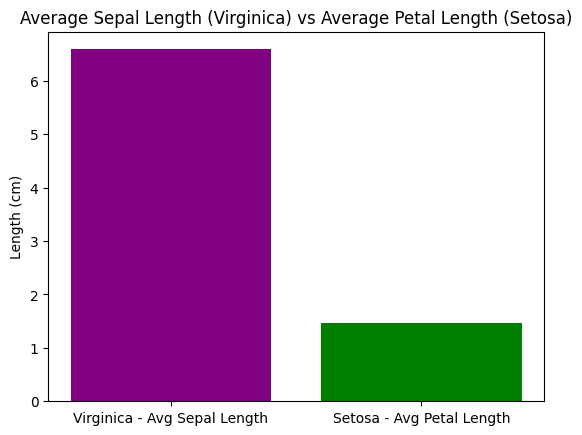

In [95]:
import matplotlib.pyplot as plt

# Add the sepal length to the Virginica data using the flower ID
virginica_sepal = virginica.merge(sepal_all[["Id", "SepalLengthCm"]], on="Id")

# Calculate the average sepal length of Virginica flowers
avg_virginica_sepal = virginica_sepal["SepalLengthCm"].mean()

# Add the petal length to the Setosa data using the flower ID
setosa_petal = setosa.merge(petal_all[["Id", "PetalLengthCm"]], on="Id")

# Calculate the average petal length of Setosa flowers
avg_setosa_petal = setosa_petal["PetalLengthCm"].mean()

# Create a bar chart to compare the two average values
plt.bar(
    ["Virginica - Avg Sepal Length", "Setosa - Avg Petal Length"],
    [avg_virginica_sepal, avg_setosa_petal],
    color=["purple", "green"]
)

# Add a label for the y-axis
plt.ylabel("Length (cm)")

# Add a title to the chart
plt.title("Average Sepal Length (Virginica) vs Average Petal Length (Setosa)")

# Display the chart
plt.show()



### `Q-10:` Create the complete dataset by uisng the below datasets:
- virginica
- versicolor
- setosa
- sepal all
- petal all

This dataset should have these below column names in order:
1. Id
2. Species
3. SepalLengthCm
4. SepalWidthCm
5. PetalLengthCm
6. PetalWidthCm

Also, the dataset should be shuffled means the `Id` column should not be in increasing or decreasing order. So, make a dataset which has the shuffled Id column. You can use `DataFrame.sample()` method to shuffle.

In [101]:
# Combine all three flower species into one dataset
# Each dataset contains only the flower ID and species name
species_all = pd.concat([virginica, versicolor, setosa], ignore_index=True)
species_all.head()

# Add the sepal measurements using the flower ID
complete_df = species_all.merge(sepal_all, on="Id")

# Add the petal measurements using the flower ID
complete_df = complete_df.merge(petal_all, on="Id")

# Arrange the columns in the required order
complete_df = complete_df[["Id", "Species", "SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]]

# Shuffle the rows to create a random order
complete_df = complete_df.sample(frac=1).reset_index(drop=True)

# Display the final dataset
complete_df

,Id,Species,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,18,Iris-setosa,5.1,3.5,1.4,0.3
1,78,Iris-versicolor,6.7,3.0,5.0,1.7
2,128,Iris-virginica,6.1,3.0,4.9,1.8
3,11,Iris-setosa,5.4,3.7,1.5,0.2
4,27,Iris-setosa,5.0,3.4,1.6,0.4
...,...,...,...,...,...,...
145,84,Iris-versicolor,6.0,2.7,5.1,1.6
146,77,Iris-versicolor,6.8,2.8,4.8,1.4
147,7,Iris-setosa,4.6,3.4,1.4,0.3
148,146,Iris-virginica,6.7,3.0,5.2,2.3


### `Q-11:` Find out the minimum and maximum **Sepal Width** and **Petal Width** of **Setosa** and **Versicolor**.

To do this:

- First, create a dataset by merging the required datasets.
- Then, use `groupby` on the **Species** column.
- Finally, find the minimum and maximum values of both **Sepal Width** and **Petal Width** for each species.

The output should look like this:

```bash
Setosa
Minimum Sepal Width: 2.3
Maximum Sepal Width: 4.4
Minimum Petal Width: 0.1
Maximum Petal Width: 0.6

**************************************************

Versicolor
Minimum Sepal Width: 2.0
Maximum Sepal Width: 3.4
Minimum Petal Width: 1.0
Maximum Petal Width: 1.8
```

In [102]:
# Display the first few rows of the datasets
setosa.head()
virginica.head()
sepal_all.head()

# Combine the Setosa and Virginica datasets
selected_species = pd.concat([setosa, virginica], ignore_index=True)

# Add the sepal and petal measurements using the flower ID
flower_data = selected_species.merge(sepal_all, on="Id").merge(petal_all, on="Id")

# Find the minimum and maximum sepal and petal widths for each species
grouped = flower_data.groupby("Species")[["SepalWidthCm", "PetalWidthCm"]].agg(["min", "max"])

# Display the grouped data
grouped

# Display the results for each species
for species in grouped.index:
    print(species)
    print("Minimum Sepal Width:", grouped.loc[species, ("SepalWidthCm", "min")])
    print("Maximum Sepal Width:", grouped.loc[species, ("SepalWidthCm", "max")])
    print("Minimum Petal Width:", grouped.loc[species, ("PetalWidthCm", "min")])
    print("Maximum Petal Width:", grouped.loc[species, ("PetalWidthCm", "max")])
    print("\n" + "*" * 50 + "\n")

Iris-setosa
Minimum Sepal Width: 2.3
Maximum Sepal Width: 4.4
Minimum Petal Width: 0.1
Maximum Petal Width: 0.6

**************************************************

Iris-virginica
Minimum Sepal Width: 2.2
Maximum Sepal Width: 3.8
Minimum Petal Width: 1.4
Maximum Petal Width: 2.5

**************************************************

